### 4.5.2 定性因子

前文讨论的输入变量均为连续型.但在实际问题中,部分输入属于定性变量.例如1.2节提及的加工仿真模型,可指定工件材料,如各类钛合金(Ti-6AL-4V,Ti-6Al6V-2Sn),或是刀具路径优化类型(无优化,切削内优化,空切优化,两者兼具).这类变量称为名义定性因子.

一般而言,系统输入变量可分为定量变量与定性变量.定量变量又包含连续型与离散数值型两类.离散数值因子仅能取若干离散取值,例如$1,2,3,\dots$.在前文的加工仿真案例中,铣刀刃数就是典型的离散数值因子.定性变量可分为名义型与有序型.有序因子的取值存在内在次序,例如等级:优秀,良好,尚可,一般,较差.在加工案例中,刀具状态就属于这类有序因子.

如何构造能够容纳定性因子的空间填充设计?现有文献中的一种思路是:将拉丁超立方设计(LHD)切分为若干分片,把每一分片分配给定性因子的一个水平.钱(2012)提出分片拉丁超立方设计(SLHD),该设计保证每一个分片本身也构成拉丁超立方设计.举例说明:设有两个连续因子$x_{1},x_{2}$,以及一个包含3个水平的名义定性因子$x_{3}$,试验预算共计9次.图4.17左图展示一组随机拉丁超立方设计,定性因子的三个水平分别用黑色圆圈(水平1),红色三角(水平2),绿色加号(水平3)标记.不难看出该设计效果不佳:定性因子取水平1时$x_1\in[0,1/3]$,取水平2时$x_1\in[1/3,2/3]$,取水平3时$x_1\in[2/3,1]$.也就是说,在定性因子的每个水平内部,$x_{1}$无法遍历完整取值区间.反观图4.17中图的分片拉丁超立方设计,性能更优:在定性因子的每一个水平下,$x_{1}$和$x_{2}$均可遍历全部取值范围.如图所示,若不考虑定性因子,整体构成一个$9\times9$的拉丁超立方设计(虚线划分);同时,定性因子每个水平内部各自形成$3\times3$的拉丁超立方设计(实线划分).

若存在$p$个定性因子,水平数依次为$L_{1},\dots,L_{p}$,则可先构造一个"新"定性因子,其水平总数为$t=\prod_{i=1}^{p}L_{i}$,随后生成拥有$t$个分片的分片拉丁超立方设计(SLHD).杨等人(2013)与尹等人(2014)给出了分片拉丁超立方设计的高效构造方法.巴等人(2015)提出极大极小分片拉丁超立方设计,保证整体设计与各个分片均具备优良的极大极小特性.图4.17右图中的分片拉丁超立方设计正是借助R语言`SLHD`包生成的极大极小分片拉丁超立方设计(巴,2015).但分片拉丁超立方设计存在缺陷:随着定性因子数量与水平数增多,设计规模会急剧膨胀.邓等人(2015)提出边缘耦合设计(MCD),可容纳更多名义因子.边缘耦合设计的构造思路为:将用于名义因子的正交表(OA,可参见吴与滨田,2021)和用于连续因子的拉丁超立方设计相结合,使得该拉丁超立方设计能够依据任意单个名义因子的水平拆分为若干小规模拉丁超立方设计.换言之,在边缘耦合设计中,连续因子的拉丁超立方设计与任意一列名义因子搭配均可构成分片拉丁超立方设计.由于边缘耦合设计针对名义因子采用正交表而非全因子组合,相比分片拉丁超立方设计能够有效缩减试验次数.然而边缘耦合设计的结构约束较强:不仅需要存在指定规模的正交表,还要求存在一类特殊拉丁超立方设计,使其与正交表的任意单列组合后均可形成分片拉丁超立方设计.约瑟夫等人(2020)提出可纳入定性因子的最大投影设计,试验次数配置更加灵活,突破了分片拉丁超立方设计与边缘耦合设计的局限.除此之外,该方法同样支持引入离散数值因子与有序因子.

>**图4.17** 包含两个定量因子($x_{1}$,$x_{2}$)与一个三水平定性因子($x_{3}$)的试验设计:随机拉丁超立方设计(左图),分片拉丁超立方设计(中图),最大投影设计(右图)

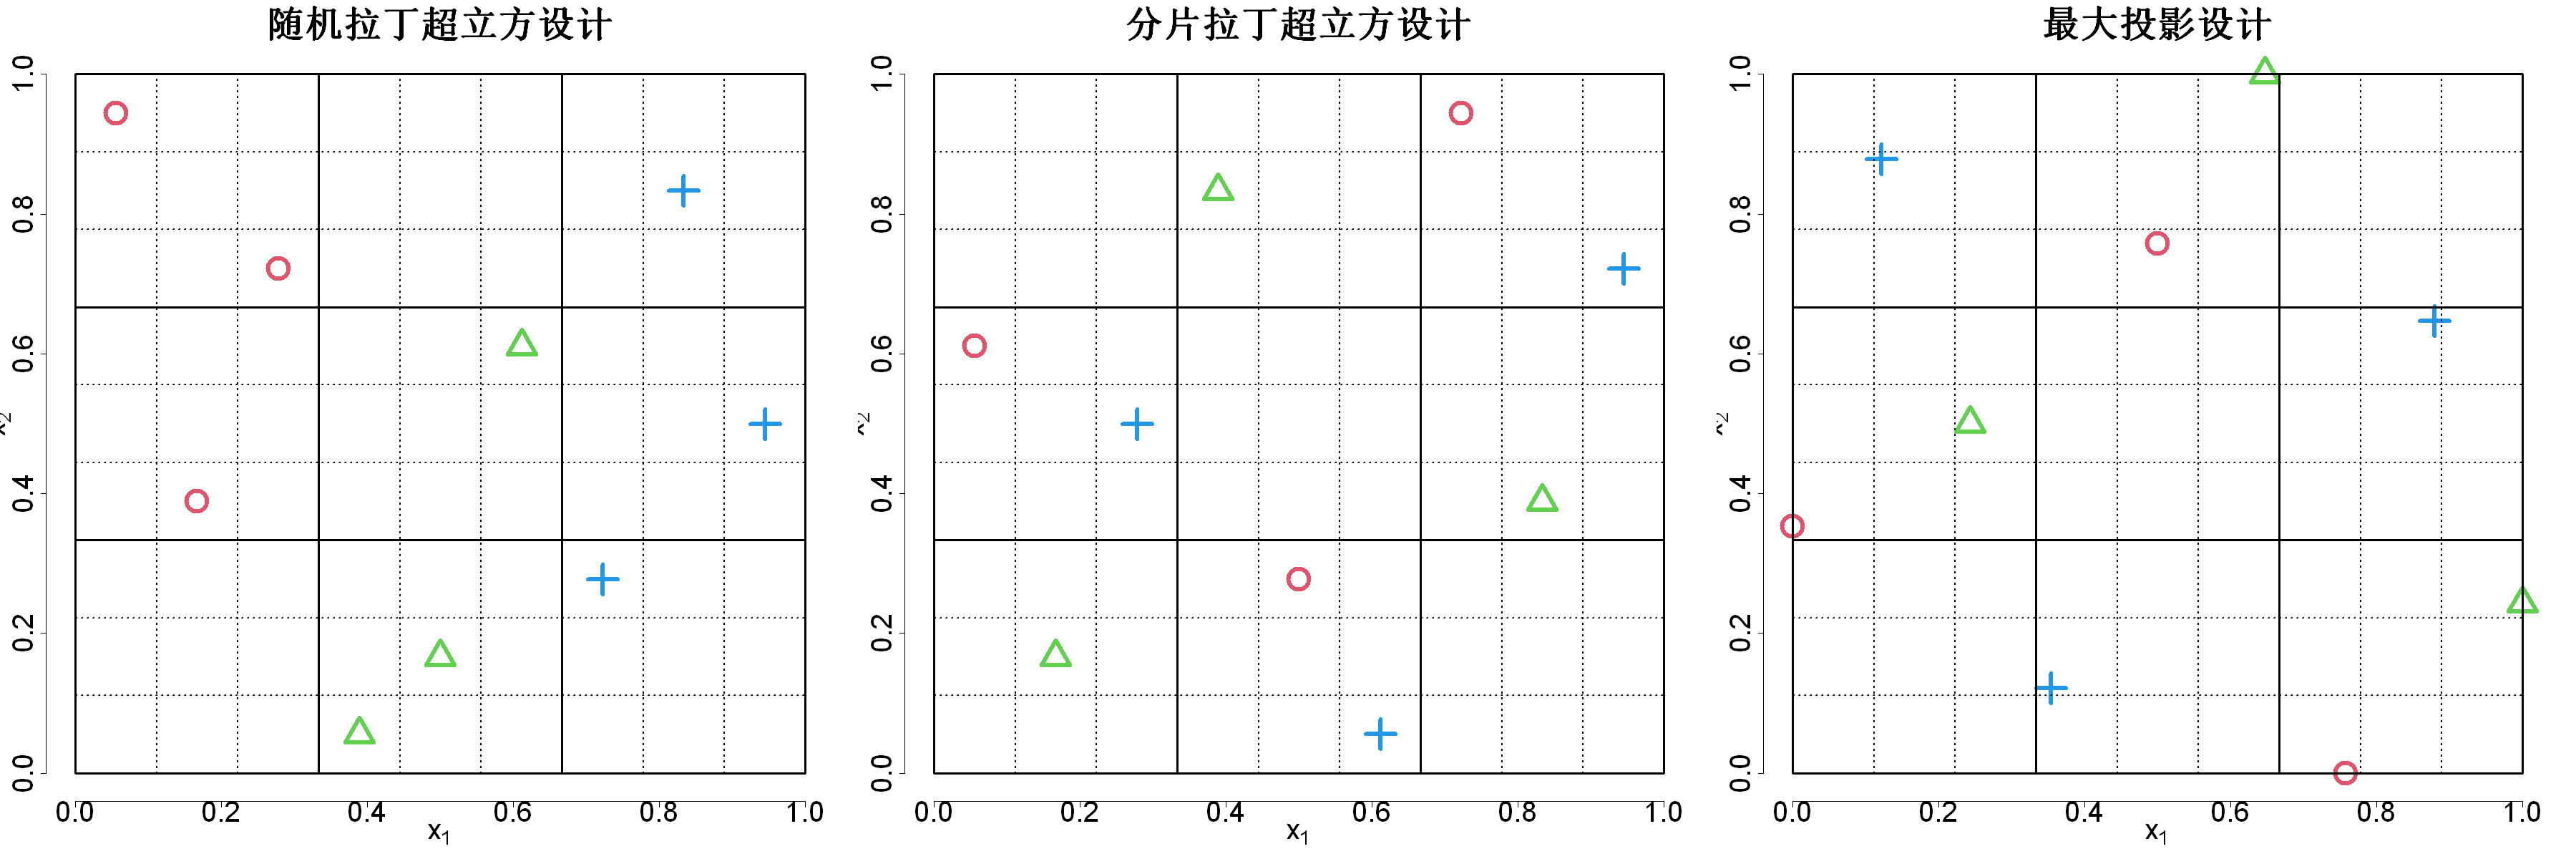

In [2]:
#图4.17

options(repr.plot.width=30,repr.plot.height=10)
par(mfrow=c(1,3))
p=2;n=9
set.seed(1)
D0=cbind(rep(1:3,c(3,3,3)),1:9,sample(1:9))
D0[,2:3]=(D0[,2:3]-.5)/9
plot(D0[,2:3],bty="n",pch=D0[,1],col=D0[,1]+1,lwd=5,xlab=expression(x[1]),ylab=expression(x[2]),main="随机拉丁超立方设计",cex=5,cex.lab=3,cex.main=4,cex.axis=3,xlim=c(0,1),ylim=c(0,1))
for(i in 1:n)
{
segments(i/n,0,i/n,1,lty=3,lwd=2)
segments(0,i/n,1,i/n,lty=3,lwd=2)
}
for(i in 0:(n/3)){
segments(3*i/n,0,3*i/n,1,lwd=3)
segments(0,3*i/n,1,3*i/n,lwd=3)
}

library(SLHD)
D1=maximinSLHD(3,3,2)$StandDesign
plot(D1[,2:3],bty="n",pch=D1[,1],col=D1[,1]+1,lwd=5,xlab=expression(x[1]),ylab=expression(x[2]),main="分片拉丁超立方设计",cex=5,cex.lab=3,cex.main=4,cex.axis=3,xlim=c(0,1),ylim=c(0,1))
for(i in 1:n)
{
segments(i/n,0,i/n,1,lty=3,lwd=2)
segments(0,i/n,1,i/n,lty=3,lwd=2)
}
for(i in 0:(n/3)){
segments(3*i/n,0,3*i/n,1,lwd=3)
segments(0,3*i/n,1,3*i/n,lwd=3)
}

set.seed(3)
library(MaxPro)
D2=MaxPro(MaxProLHD(n,p)$Design)$Design
ini=cbind(D2,rep(1:3,c(3,3,3)))
D=MaxProQQ(InitialDesign=ini,p_nom=1)$Design
plot(D[,1:2],bty="n",pch=D[,3],col=D[,3]+1,lwd=5,xlab=expression(x[1]),ylab=expression(x[2]),main="最大投影设计",cex=5,cex.lab=3,cex.main=4,cex.axis=3)
for(i in 0:n)
{
segments(i/n,0,i/n,1,lty=3,lwd=2)
segments(0,i/n,1,i/n,lty=3,lwd=2)
}
for(i in 0:(n/3)){
segments(3*i/n,0,3*i/n,1,lwd=3)
segments(0,3*i/n,1,3*i/n,lwd=3)
}
par(mfrow=c(1,1))

在讨论适用于定性因子的最大投影设计之前,我们先要掌握如何拟合包含定性因子的高斯过程(GP)模型.首先采用评分法将有序因子转化为离散数值因子(参见吴与滨田,2021,第14章).例如,某有序因子包含"较差","中等","良好"三个水平,试验人员可依据分类特征选取一组离散数值,如$\{1,2,3\}$或$\{1,4,5\}$代表这三个有序水平.因此,下文仅需考虑连续因子,名义因子与离散数值因子,默认有序因子已通过评分法转换为离散数值因子.

钱等人(2008)提出多种相关结构构造方案,同时建立一套通用框架,用于构建同时包含定量因子与名义型定性因子的高斯过程(GP)模型.本文针对名义因子采用约瑟夫与德拉尼(2007)所使用的可交换相关结构:

$$R(\boldsymbol{w}_{i}-\boldsymbol{w}_{j};\alpha,\beta,\gamma)=\exp\left(-\sum_{l=1}^{p_{1}}\alpha_{l}|x_{il}-x_{jl}|-\sum_{k=1}^{p_{2}}\beta_{k}|u_{ik}-u_{jk}|-\sum_{h=1}^{p_{3}}\gamma_{h}I(v_{ih}\ne v_{jh})\right)\tag{4.31}$$

式中$\boldsymbol{w}_{i}=(\boldsymbol{x}_{i},\boldsymbol{u}_{i},\boldsymbol{v}_{i})$;$\boldsymbol{x}$为$p_1$个连续因子;$\boldsymbol{u}$为$p_2$个离散数值因子(包含有序因子);$\boldsymbol{v}$为$p_3$个名义因子;指示函数$I(v_{ih}\ne v_{jh})$满足:若$v_{ih}\ne v_{jh}$取值为1,否则取值为0.假定离散数值因子同样缩放至区间$[0,1]$,使三类因子对应的相关参数处于同一量纲.与式(4.24)中的高斯相关函数不同,此处连续因子采用指数相关函数.后文将会说明:对指数相关函数的相关参数赋予有信息先验,能够推导出与高斯相关函数情形一致的最大投影准则.这种基于有信息先验的改进对离散数值因子至关重要,原因是试验设计中离散数值因子无法取到$n$个不同水平.

对相关参数设定如下先验分布:

$$\begin{align*}\alpha_{l}&\stackrel{i.i.d.}{\sim}\mathrm{Gamma}(2,\overline{\alpha}_{l}),\;l=1,\dots,p_{1}\\\beta_{k}&\stackrel{i.i.d.}{\sim}\mathrm{Gamma}(2,\overline{\beta}_{k}),\;k=1,\dots,p_{2}\\\gamma_{h}&\stackrel{i.i.d.}{\sim}\mathrm{Gamma}(2,\overline{\gamma}_{h}),\;h=1,\dots,p_{3}\end{align*}$$

选取伽马先验能够推导出目标函数的显式表达式.同时将伽马分布的形状参数设定为2,使得推导结果与式(4.23)仅包含连续因子情形下的最大投影准则保持一致.由此可得

$$\begin{align*}&\mathbb{E}[\|\boldsymbol{R}-\boldsymbol{I}_{n}\|_{1}]\\=\;&\iiint\sum_{i=1}^{n}\sum_{j\ne i}R(\boldsymbol{w}_{i}-\boldsymbol{w}_{j};\alpha,\beta,\gamma)\prod_{l=1}^{p_{1}}\overline{\alpha}_{l}^{2}\alpha_{l}e^{-\overline{\alpha}_{l}\alpha_{l}}\prod_{k=1}^{p_{2}}\overline{\beta}_{k}^{2}\beta_{k}e^{-\overline{\beta}_{k}\beta_{k}}\prod_{h=1}^{p_{3}}\overline{\gamma}_{h}^{2}\gamma_{h}e^{-\overline{\gamma}_{h}\gamma_{h}}\mathrm{d}\alpha\mathrm{d}\beta\mathrm{d}\gamma\\=\;&\sum_{i=1}^{n}\sum_{j\ne i}\left(\prod_{l=1}^{p_{1}}\int\overline{\alpha}_{l}^{2}\alpha_{l}e^{-\left(|x_{il}-x_{jl}|+\overline{\alpha}_{l}\right)\alpha_{l}}\mathrm{d}\alpha_{l}\right)\left(\prod_{k=1}^{p_{2}}\int\overline{\beta}_{k}^{2}\beta_{k}e^{-\left(|u_{ik}-u_{jk}|+\overline{\beta}_{k}\right)\beta_{k}}\mathrm{d}\beta_{k}\right)\left(\prod_{h=1}^{p_{3}}\int\overline{\gamma}_{h}^{2}\gamma_{h}e^{-\left(I(v_{ih}\ne v_{jh})+\overline{\gamma}_{h}\right)\gamma_{h}}\mathrm{d}\gamma_{h}\right)\\=\;&\sum_{i=1}^{n}\sum_{j\ne i}\prod_{l=1}^{p_{1}}\frac{\overline{\alpha}_{l}^{2}}{\left(|x_{il}-x_{jl}|+\overline{\alpha}_{l}\right)^{2}}\prod_{k=1}^{p_{2}}\frac{\overline{\beta}_{k}^{2}}{\left(|u_{ik}-u_{jk}|+\overline{\beta}_{k}\right)^{2}}\prod_{h=1}^{p_{3}}\frac{\overline{\gamma}_{h}^{2}}{\left(I(v_{ih}\ne v_{jh})+\overline{\gamma}_{h}\right)^{2}}\end{align*}$$

由此得到新的设计准则,即最小化下式:

$$\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\prod_{l=1}^{p_{1}}\left(|x_{il}-x_{jl}|+\overline{\alpha}_{l}\right)^{2}\prod_{k=1}^{p_{2}}\left(|u_{ik}-u_{jk}|+\overline{\beta}_{k}\right)^{2}\prod_{h=1}^{p_{3}}\left(I(v_{ih}\ne v_{jh})+\overline{\gamma}_{h}\right)^{2}}\tag{4.32}$$

直观来看,为提升式(4.32)对设计变动的敏感度,应选取较小的$\overline{\alpha}_{l}$,$\overline{\beta}_{k}$和$\overline{\gamma}_{h}$.对于连续因子,可直接令$\overline{\alpha}_{l}=0$($l=1,\dots,p_{1}$),该设置能够促使每个连续因子取得$n$个不同水平.但对于名义因子与离散数值因子,单个因子所能取到的总水平数小于$n$.因此必须满足$\overline{\beta}_{k}>0$($k=1,\dots,p_{2}$)与$\overline{\gamma}_{h}>0$($h=1,\dots,p_{3}$),避免存在某组$(i,j)$使得$u_{ik}=u_{jk}$或$v_{ih}=v_{jh}$时,式(4.32)分母等于0.设$L_{h}$为第$h$个名义因子的不同水平数量,$h=1,\dots,p_{3}$.由于$\mathbb{P}(I(v_{ih}\ne v_{jh})=0)=1/L_{h}$,可得$\mathbb{E}[I(v_{ih}\ne v_{jh})]=1-1/L_{h}$,$h=1,\dots,p_{3}$.据此建议取$\overline{\gamma}_{h}=1/L_{h}$,该取值是能够使$\mathbb{E}[I(v_{ih}\ne v_{jh})+\overline{\gamma}_{h}]$与$L_{h}$无关的最小可行值.同理,针对离散数值因子,令$\overline{\beta}_{k}=1/m_{k}$,其中$m_{k}$为第$k$个离散数值因子的水平数.不难发现,随着$m_{k}$增大,离散数值因子的特性将趋近于连续因子,对应的$\overline{\beta}_{k}$也会如预期般趋于0.

基于上述超参数取值方案,最优设计准则可写为

$$\min_{D}\sum_{i=1}^{n-1}\sum_{i\ne j}\frac{1}{\prod_{l=1}^{p_{1}}(x_{il}-x_{jl})^{2}\prod_{k=1}^{p_{2}}\left(|u_{ik}-u_{jk}|+\frac{1}{m_{k}}\right)^{2}\prod_{h=1}^{p_{3}}\left(I(v_{ih}\ne v_{jh})+\frac{1}{L_{h}}\right)^{2}}\tag{4.33}$$

当仅存在连续因子($p_{1}\ge1$,$p_{2}=p_{3}=0$)时,该准则退化为式(4.23)中的最大投影准则.因此该准则继承了最大投影设计的全部优良性质,不仅能够在完整试验区域内实现空间填充,在向任意低维子空间投影时同样具备良好的空间填充效果.对于名义因子,该准则与徐(2002)在构造混合水平正交表及近似正交表时提出的$J_{2}$最优准则思路相近,后者通过最大化各行之间的相异程度实现设计优化,目标形式为$\min_{D}\sum_{i=1}^{n-1}\sum_{j=i+1}^{n}\left(\sum_{h=1}^{p_{3}}I(v_{ih}=v_{jh})\right)^{2}$.

可借助R包`MaxPro`中的`MaxProQQ`函数生成式(4.33)对应的最大投影设计(巴与约瑟夫,2018).包含两个连续因子,一个三水平名义定性因子,共计9次试验的最大投影设计如图4.17右图所示.可以观察到,尽管优化过程并未施加相关约束,该最大投影设计天然具备分片拉丁超立方设计的特性.与此同时,最大投影设计灵活性极强:可针对任意试验次数,任意数量的定量与定性因子构造.奇特尔等人(2025)介绍了`MaxProQQ`在液体配方设计领域的最新应用案例.